In [1]:
# Uncomment these in a fresh notebook environment.
#%pip install -r ../requirements.txt
#%pip install -e ..

In [2]:
%reload_ext autoreload
%autoreload 2

from marl_tsc.network_types import CityNetwork, GridNetwork
from marl_tsc.simulation_generator import SimulationGenerator
from marl_tsc.training import train_ppo, evaluate_policy, export_policy_replay, plot_evaluation_results, plot_training_histories
from marl_tsc.mappo import train_mappo
from marl_tsc.baselines import random_actions, fixed_time_actions
from pathlib import Path
import matplotlib.pyplot as plt

GREEN_PHASE_COUNT = None  # Let SUMO/network discovery choose the phase count.
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "main_flow.ipynb").exists() else NOTEBOOK_DIR
OUTPUT_DIR = PROJECT_ROOT / "outputs"

## Generate the SUMO simulation files

This default setup is a small `4x4` grid with four traffic-light agents. Change `network` to use a UK city network instead.


In [3]:
EPISODE_STEPS = 600
SECONDS_PER_ACTION = 5
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION

# Keep vehicles entering slightly longer than the episode runs.
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)

EVALUATION_EPISODES = 3
TOTAL_TIMESTEPS = 100_000
MIN_GREEN_SECONDS = 10
SWITCH_PENALTY = 0.1

# network = GridNetwork()
network = CityNetwork(city_name="Bristol, UK", radius=150)

generator = SimulationGenerator(
    output_dir=OUTPUT_DIR,
    network=network,
    trip_begin=0,
    trip_end=TRAFFIC_SPAWN_DURATION,
    trip_period=4,
    seed=42,
)

paths = generator.generate_all()
traffic_light_ids = list(paths.traffic_light_ids)
print(f"Generated SUMO config: {paths.config_file}")
print(f"Simulation horizon: {SIMULATION_DURATION}s")
print(f"Traffic spawn duration: {TRAFFIC_SPAWN_DURATION}s")
print("Traffic-light agent count:", len(traffic_light_ids))

Generated SUMO config: C:\Code\marl-tsc\outputs\config.sumocfg
Simulation horizon: 3000s
Traffic spawn duration: 3600s
Traffic-light agent count: 8


## Train

PPO uses parameter sharing through the PettingZoo/SuperSuit/SB3 wrapper. MAPPO adds a centralized critic and a shared decentralized actor.

### PPO

[PPO] Step 4800 | Network Episode Return: -186.60
[PPO] Step 9600 | Network Episode Return: -188.16
[PPO] Step 14400 | Network Episode Return: -233.29
[PPO] Step 19200 | Network Episode Return: -215.96
[PPO] Step 24000 | Network Episode Return: -204.07
[PPO] Step 28800 | Network Episode Return: -186.58
[PPO] Step 33600 | Network Episode Return: -189.21
[PPO] Step 38400 | Network Episode Return: -198.69
[PPO] Step 43200 | Network Episode Return: -220.40
[PPO] Step 48000 | Network Episode Return: -182.13
[PPO] Step 52800 | Network Episode Return: -220.49
[PPO] Step 57600 | Network Episode Return: -270.66
[PPO] Step 62400 | Network Episode Return: -187.29
[PPO] Step 67200 | Network Episode Return: -179.54
[PPO] Step 72000 | Network Episode Return: -176.52
[PPO] Step 76800 | Network Episode Return: -204.76
[PPO] Step 81600 | Network Episode Return: -199.88
[PPO] Step 86400 | Network Episode Return: -234.15
[PPO] Step 91200 | Network Episode Return: -148.43
[PPO] Step 96000 | Network Episod

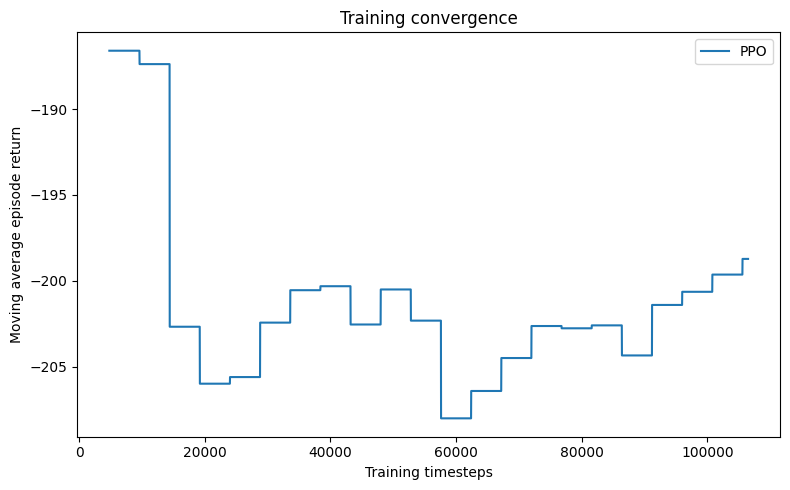

In [4]:
ppo_model, ppo_history, ppo_model_path = train_ppo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={
        "green_phase_count": GREEN_PHASE_COUNT,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        "switch_penalty": SWITCH_PENALTY,
    },
)

fig, ax = plot_training_histories(ppo_history)
plt.show()

### MAPPO

[MAPPO] Episode 1 | Return: -136.27 | Total Steps: 600
[MAPPO] Episode 2 | Return: -167.35 | Total Steps: 1200
[MAPPO] Episode 3 | Return: -162.85 | Total Steps: 1800
[MAPPO] Episode 4 | Return: -200.56 | Total Steps: 2400
[MAPPO] Episode 5 | Return: -154.88 | Total Steps: 3000
[MAPPO] Episode 6 | Return: -135.55 | Total Steps: 3600
[MAPPO] Episode 7 | Return: -168.54 | Total Steps: 4200
[MAPPO] Episode 8 | Return: -139.54 | Total Steps: 4800
[MAPPO] Episode 9 | Return: -139.78 | Total Steps: 5400
[MAPPO] Episode 10 | Return: -156.71 | Total Steps: 6000
[MAPPO] Episode 11 | Return: -147.01 | Total Steps: 6600
[MAPPO] Episode 12 | Return: -170.24 | Total Steps: 7200
[MAPPO] Episode 13 | Return: -146.80 | Total Steps: 7800
[MAPPO] Episode 14 | Return: -151.55 | Total Steps: 8400
[MAPPO] Episode 15 | Return: -140.70 | Total Steps: 9000
[MAPPO] Episode 16 | Return: -144.90 | Total Steps: 9600
[MAPPO] Episode 17 | Return: -137.06 | Total Steps: 10200
[MAPPO] Episode 18 | Return: -153.28 | T

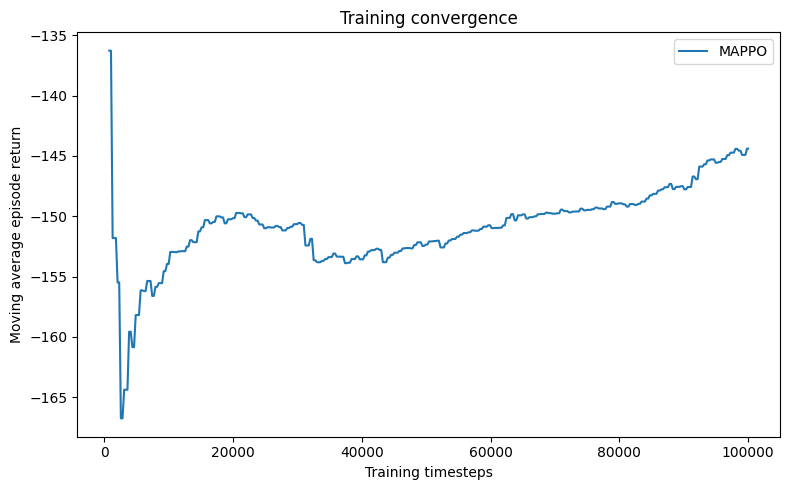

In [5]:
mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={
        "green_phase_count": GREEN_PHASE_COUNT,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        "switch_penalty": SWITCH_PENALTY,
    },
)

fig, ax = plot_training_histories(mappo_history)
plt.show()

## Export SUMO GUI replay

This writes a replay of a policy on a network that can be opened directly from the SUMO GUI.

In [6]:
replay_config = export_policy_replay(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policy=mappo_model,
    output_dir=OUTPUT_DIR / "replays" / "mappo",
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={
        "green_phase_count": GREEN_PHASE_COUNT,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        "switch_penalty": SWITCH_PENALTY,
    },
)

print(f"Open this file in SUMO GUI: {replay_config}")

Open this file in SUMO GUI: C:\Code\marl-tsc\outputs\replays\mappo\replay.sumocfg


## Evaluate policies

The final comparison uses the same evaluation seeds for every policy.


In [7]:
def get_evaluation_results(policy):
    return evaluate_policy(
        config_file=paths.config_file,
        traffic_light_ids=traffic_light_ids,
        policy=policy,
        episodes=EVALUATION_EPISODES,
        max_steps=EPISODE_STEPS,
        seed=42,
        env_kwargs={
            "green_phase_count": GREEN_PHASE_COUNT,
            "min_green_seconds": MIN_GREEN_SECONDS,
            "seconds_per_action": SECONDS_PER_ACTION,
            "switch_penalty": SWITCH_PENALTY,
            "global_metric_interval": 10,
        },
    )

In [8]:
policies = {
    "Random": random_actions,
    "Fixed-Time": fixed_time_actions,
    "Shared PPO": ppo_model,
    "MAPPO": mappo_model,
}

policy_results = {}

for name, policy in policies.items():
    print(f"Evaluating {name} model")
    policy_result = get_evaluation_results(policy)
    policy_results[name] = policy_result

Evaluating Random model
Finished Evaluation Episode 1/3 - Total Reward: -1431.70
Finished Evaluation Episode 2/3 - Total Reward: -1297.66
Finished Evaluation Episode 3/3 - Total Reward: -1331.87
Evaluating Fixed-Time model
Finished Evaluation Episode 1/3 - Total Reward: -10790.86
Finished Evaluation Episode 2/3 - Total Reward: -18829.51
Finished Evaluation Episode 3/3 - Total Reward: -8870.40
Evaluating Shared PPO model
Finished Evaluation Episode 1/3 - Total Reward: -10601.42
Finished Evaluation Episode 2/3 - Total Reward: -9107.86
Finished Evaluation Episode 3/3 - Total Reward: -8812.91
Evaluating MAPPO model
Finished Evaluation Episode 1/3 - Total Reward: -1618.24
Finished Evaluation Episode 2/3 - Total Reward: -2221.75
Finished Evaluation Episode 3/3 - Total Reward: -1460.86


In [9]:
for name, result in policy_results.items():
    print(
        f"{name:10} "
        f"reward={result['mean_total_reward']:.1f}  "
        f"queue={result['mean_local_queue']:.3f}  "
        f"wait={result['mean_waiting_time']:.2f}  "
        f"max_wait={result['mean_max_waiting_time']:.2f}"
    )

Random     reward=-1353.7  queue=0.177  wait=19.51  max_wait=193.33
Fixed-Time reward=-12830.3  queue=1.069  wait=127.81  max_wait=1565.00
Shared PPO reward=-9507.4  queue=1.059  wait=124.19  max_wait=875.33
MAPPO      reward=-1766.9  queue=0.250  wait=22.15  max_wait=258.00


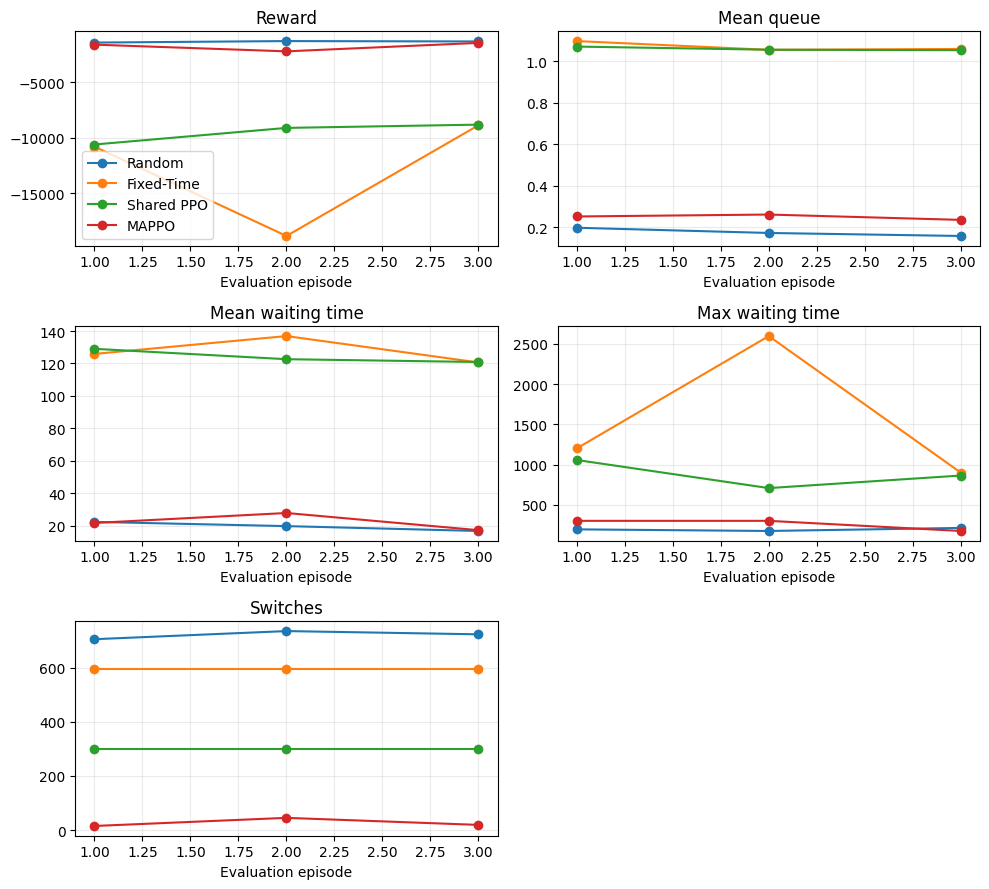

In [10]:
fig, axes = plot_evaluation_results(policy_results)
plt.show()